IMPORT LIBRARIES

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyodbc 


LOAD TABLE FROM DATABASE

In [3]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=MSI\SQLEXPRESS;"
    "DATABASE=churn_analysis;"
    "Trusted_Connection=yes;"
    )

<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:3: SyntaxWarning: invalid escape sequence '\S'
C:\Users\rahul\AppData\Local\Temp\ipykernel_6124\425476870.py:3: SyntaxWarning: invalid escape sequence '\S'
  "SERVER=MSI\SQLEXPRESS;"


In [6]:
churn = pd.read_sql('SELECT * FROM cleaned_customer_churn', conn)

C:\Users\rahul\AppData\Local\Temp\ipykernel_6124\2225589287.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  churn = pd.read_sql('SELECT * FROM cleaned_customer_churn', conn)


In [7]:
churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,charge_category
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,Month-to-month,Electronic check,29.850000,29.850000,No,0-1 YEAR,LOW
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,One year,Mailed check,56.950001,1889.500000,No,2-4 YEARS,MEDIUM
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Month-to-month,Mailed check,53.849998,108.150002,Yes,0-1 YEAR,MEDIUM
3,7795-CFOCW,Male,0,No,No,45,No,DSL,One year,Bank transfer (automatic),42.299999,1840.750000,No,2-4 YEARS,MEDIUM
4,9237-HQITU,Female,0,No,No,2,Yes,Fiber optic,Month-to-month,Electronic check,70.699997,151.649994,Yes,0-1 YEAR,HIGH


TABLE OVERVIEW

In [8]:
churn.shape

(7043, 15)

In [9]:
# check columns types
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       7043 non-null   object 
 1   gender           7043 non-null   object 
 2   SeniorCitizen    7043 non-null   int64  
 3   Partner          7043 non-null   object 
 4   Dependents       7043 non-null   object 
 5   tenure           7043 non-null   int64  
 6   PhoneService     7043 non-null   object 
 7   InternetService  7043 non-null   object 
 8   Contract         7043 non-null   object 
 9   PaymentMethod    7043 non-null   object 
 10  MonthlyCharges   7043 non-null   float64
 11  TotalCharges     7043 non-null   float64
 12  Churn            7043 non-null   object 
 13  tenure_group     7043 non-null   object 
 14  charge_category  7043 non-null   object 
dtypes: float64(2), int64(2), object(11)
memory usage: 825.5+ KB


CHECK CHURN DISTRIBUTION

In [10]:
churn['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

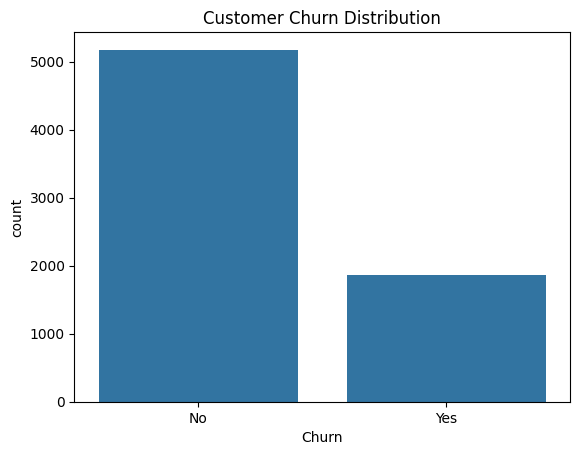

In [11]:
sns.countplot(x='Churn', data=churn)
plt.title('Customer Churn Distribution')
plt.show()

CHURN BY CONTRACT TYPE

In [17]:
churn.groupby(churn['Churn'])['Contract'].value_counts()

Churn  Contract      
No     Month-to-month    2220
       Two year          1647
       One year          1307
Yes    Month-to-month    1655
       One year           166
       Two year            48
Name: count, dtype: int64

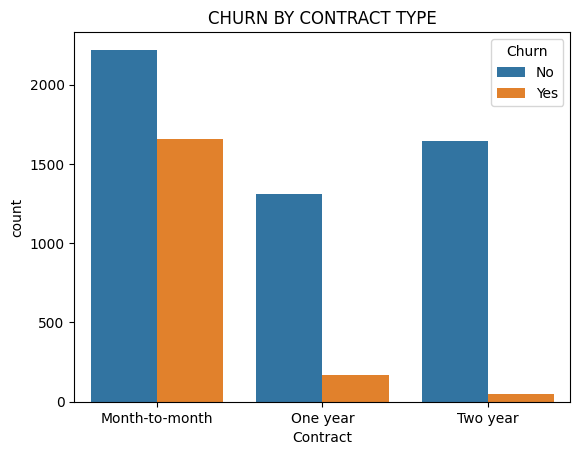

In [12]:
sns.countplot(x='Contract', hue='Churn', data=churn)
plt.title('CHURN BY CONTRACT TYPE')
plt.show()

CHURN BY TENURE

In [19]:
churn.groupby(churn['Churn'])['tenure'].value_counts()

Churn  tenure
No     72        356
       1         233
       71        164
       2         115
       70        108
                ... 
Yes    71          6
       72          6
       62          5
       63          4
       64          4
Name: count, Length: 145, dtype: int64

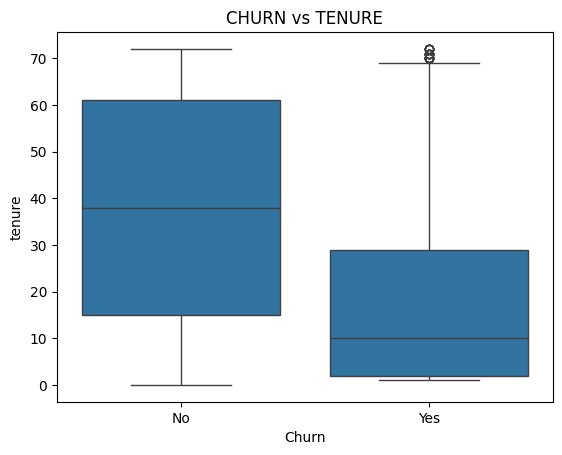

In [24]:
sns.boxplot(x='Churn', y='tenure', data=churn)
plt.title('CHURN vs TENURE')
plt.show()

CHURN BY MONTHLY CHARGES

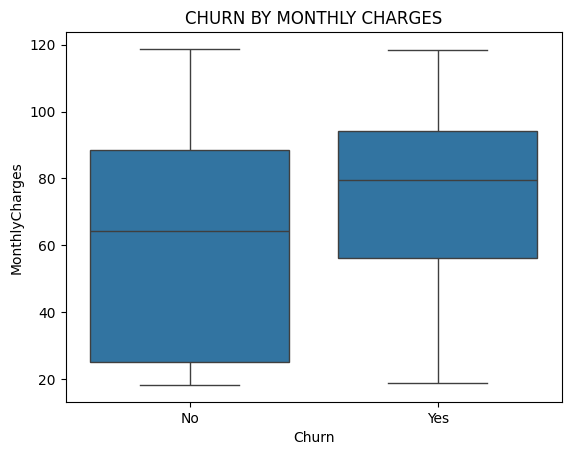

In [21]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=churn)
plt.title('CHURN BY MONTHLY CHARGES')
plt.show()

CHURN BY INTERNET SERVICE

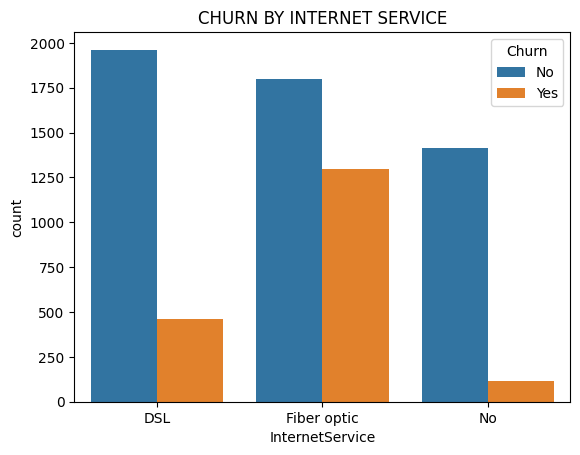

In [25]:
sns.countplot(x='InternetService', hue='Churn', data=churn)
plt.title('CHURN BY INTERNET SERVICE')
plt.show()

CORRELATION ANALYSIS

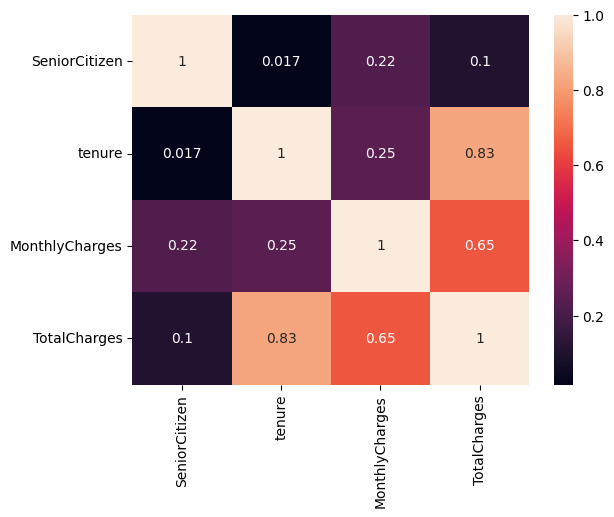

In [26]:
numeric_cols = churn.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_cols.corr(), annot=True)
plt.show('CORRELATION MATRIX')
plt.show()